In [4]:
"""
UFC Fight Outcome Predictor
----------------------------
Predicts whether the Red corner fighter wins a UFC fight
using pre-fight historical statistics.

Key design decisions:
- Temporal split (not random) to avoid future data leakage
- Imputation fit only on training data to avoid leakage
- Pipeline to prevent scaling errors
- Features filtered to pre-fight stats only (no in-fight stats)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay

In [5]:
# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
ufc     = pd.read_csv("C:/Users/franm/Desktop/github/UFC.csv")
fights  = pd.read_csv("C:/Users/franm/Desktop/github/fight_details.csv")
events  = pd.read_csv("C:/Users/franm/Desktop/github/event_details.csv")
fighters = pd.read_csv("C:/Users/franm/Desktop/github/fighter_details.csv")


In [6]:
# ─────────────────────────────────────────────
# 2. MERGE & BUILD TARGET
# ─────────────────────────────────────────────
# Add fighter names so we can build a binary target
df = ufc.merge(
    fights[['fight_id', 'r_name', 'b_name']],
    on='fight_id',
    how='left',
    suffixes=('', '_fights')   # keeps original col names clean
)
df = df.copy()
# Resolve the name column (handles potential suffix from merge)
r_col = 'r_name' if 'r_name' in df.columns else 'r_name_fights'

# Binary target: 1 = Red wins, 0 = Blue wins
df['red_win'] = (df['winner'] == df[r_col]).astype(int)

# Sanity check
assert df['red_win'].sum() > 0, "red_win is all zeros - check column names"

# Sort chronologically — CRITICAL to avoid temporal leakage
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

In [7]:
# ─────────────────────────────────────────────
# 3. FEATURE SELECTION (pre-fight stats only)
# ─────────────────────────────────────────────
# Only historical aggregate stats (avg, acc, def, sapm, splm)
# Exclude anything that measures what happened IN the fight
VALID   = ['avg', 'acc', 'def', 'sapm', 'splm']
INVALID = ['landed', 'atmpted', 'attempted', 'ctrl', 'kd',
           'head', 'body', 'leg', 'dist', 'clinch']

features = [
    col for col in df.columns
    if (col.startswith('r_') or col.startswith('b_'))
    and any(k in col for k in VALID)
    and not any(k in col for k in INVALID)
    and df[col].dtype != 'object'
]

X = df[features].copy()
y = df['red_win']

print(f"Features selected: {len(features)}")
print(features)

Features selected: 24
['r_sig_str_acc', 'r_total_str_acc', 'r_td_acc', 'r_ground_acc', 'r_splm', 'r_str_acc', 'r_sapm', 'r_str_def', 'r_td_avg', 'r_td_avg_acc', 'r_td_def', 'r_sub_avg', 'b_sig_str_acc', 'b_total_str_acc', 'b_td_acc', 'b_ground_acc', 'b_splm', 'b_str_acc', 'b_sapm', 'b_str_def', 'b_td_avg', 'b_td_avg_acc', 'b_td_def', 'b_sub_avg']


In [17]:
# ─────────────────────────────────────────────
# 5. TIME SERIES CROSS-VALIDATION
# ─────────────────────────────────────────────

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, accuracy_score

tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=200, random_state=42,
                                         eval_metric='logloss', verbosity=0),
}

results = {}

print(f"\n{'─'*60}")
print(f"{'Modelo':<25} {'Mean AUC':>10} {'Std AUC':>10}")
print(f"{'─'*60}")

for name, clf in models.items():
    
    auc_scores = []
    
    for train_index, test_index in tscv.split(X):
        
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler",  StandardScaler()),
            ("model",   clf)
        ])
        
        pipe.fit(X_train, y_train)
        probs = pipe.predict_proba(X_test)[:, 1]
        auc   = roc_auc_score(y_test, probs)
        
        auc_scores.append(auc)
    
    results[name] = {
        "mean_auc": np.mean(auc_scores),
        "std_auc":  np.std(auc_scores),
        "pipeline": pipe  # último fold entrenado
    }
    
    print(f"{name:<25} {np.mean(auc_scores):>10.3f} {np.std(auc_scores):>10.3f}")

print(f"{'─'*60}")

best_name = max(results, key=lambda k: results[k]["mean_auc"])
best = results[best_name]

print(f"\nMejor modelo: {best_name} (Mean AUC {best['mean_auc']:.3f})")


────────────────────────────────────────────────────────────
Modelo                      Mean AUC    Std AUC
────────────────────────────────────────────────────────────
Logistic Regression            0.798      0.021
Random Forest                  0.819      0.036
XGBoost                        0.817      0.047
────────────────────────────────────────────────────────────

Mejor modelo: Random Forest (Mean AUC 0.819)


In [18]:
# ─────────────────────────────────────────────
# 6. FINAL TRAINING ON FULL DATASET
# ─────────────────────────────────────────────

final_model = models[best_name]

final_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler",  StandardScaler()),
    ("model",   final_model)
])

final_pipeline.fit(X, y)

print(f"\nModelo final entrenado en todo el dataset: {best_name}")


Modelo final entrenado en todo el dataset: Random Forest


In [23]:
# ─────────────────────────────────────────────
# 6. FINAL TEMPORAL SPLIT (solo para visualización)
# ─────────────────────────────────────────────

split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

final_model = models[best_name]

final_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler",  StandardScaler()),
    ("model",   final_model)
])

final_pipeline.fit(X_train, y_train)

probs = final_pipeline.predict_proba(X_test)[:, 1]
preds = (probs > 0.5).astype(int)

accuracy = accuracy_score(y_test, preds)
auc = roc_auc_score(y_test, probs)

print(f"\nFinal split performance:")
print(f"Accuracy: {accuracy:.3f}")
print(f"AUC:      {auc:.3f}")


Final split performance:
Accuracy: 0.774
AUC:      0.857


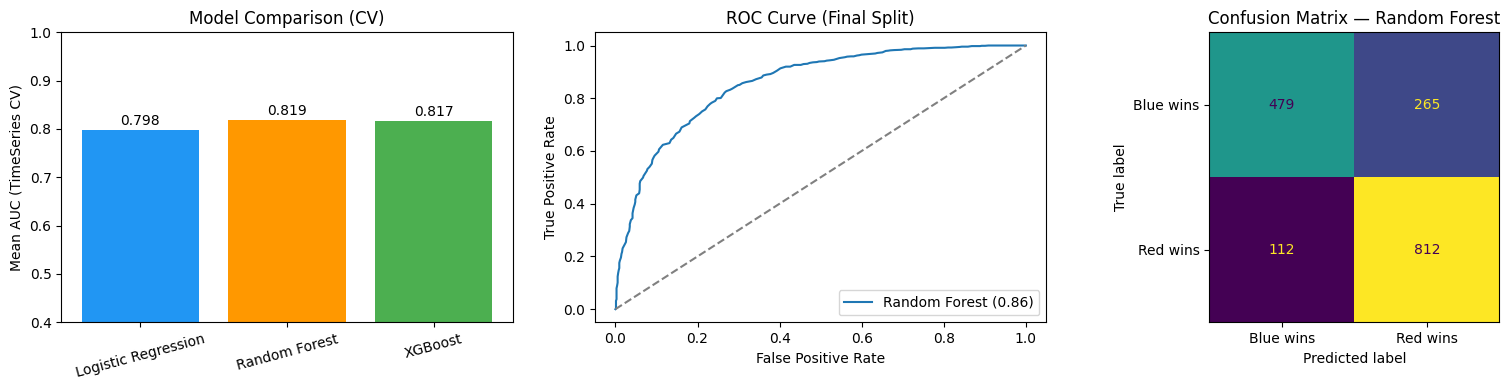

In [28]:
# ─────────────────────────────────────────────
# 7. PLOTS
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 7a. Mean AUC comparison (CV)
model_names = list(results.keys())
auc_values  = [results[n]["mean_auc"] for n in model_names]
colors      = ["#2196F3", "#FF9800", "#4CAF50"]

axes[0].bar(model_names, auc_values, color=colors)
axes[0].set_ylim(0.4, 1.0)
axes[0].set_ylabel("Mean AUC (TimeSeries CV)")
axes[0].set_title("Model Comparison (CV)")
axes[0].tick_params(axis='x', rotation=15)

for i, v in enumerate(auc_values):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center')

# 7b. ROC curve (final split only)
fpr_, tpr_, _ = roc_curve(y_test, probs)
axes[1].plot(fpr_, tpr_, label=f"{best_name} ({auc:.2f})")
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Final Split)")
axes[1].legend()

# 7c. Confusion Matrix (final split)
ConfusionMatrixDisplay.from_predictions(
    y_test, preds,
    display_labels=["Blue wins", "Red wins"],
    ax=axes[2],
    colorbar=False
)
axes[2].set_title(f"Confusion Matrix — {best_name}")

plt.tight_layout()
plt.savefig("C:/Users/franm/Desktop/github/results/evaluation_plots.png", dpi=150)
plt.show()

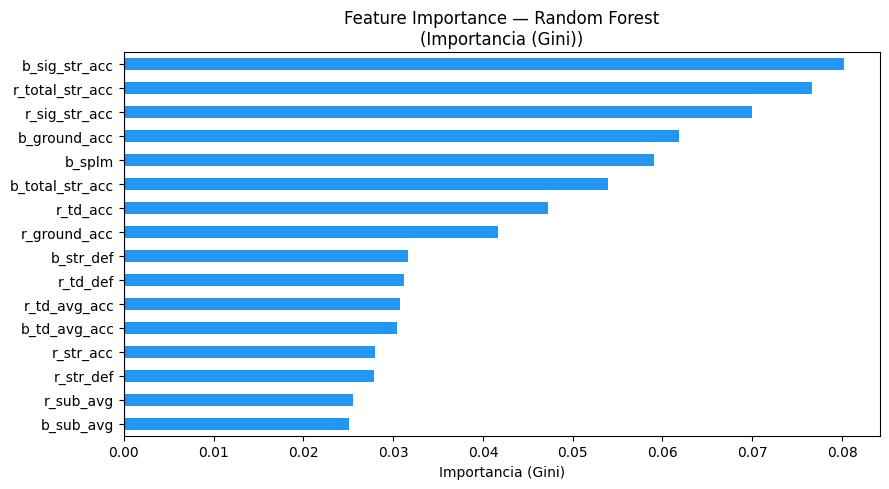

In [29]:
# ─────────────────────────────────────────────
# 8. FEATURE IMPORTANCE
# ─────────────────────────────────────────────
# Para Logistic Regression usamos coeficientes.
# Para Random Forest / XGBoost usamos feature_importances_.

best_clf = final_pipeline.named_steps["model"]
all_features = list(X_train.columns)

if hasattr(best_clf, "coef_"):
    importances = best_clf.coef_[0]
    importance_label = "Coeficiente (Logistic Regression)"
else:
    importances = best_clf.feature_importances_
    importance_label = "Importancia (Gini)"

imp_df = pd.Series(importances, index=all_features).sort_values()

# Mostrar solo las 15 más importantes (positivas y negativas)
imp_df = pd.concat([imp_df.head(8), imp_df.tail(8)])

fig, ax = plt.subplots(figsize=(9, 5))
imp_df.plot(kind='barh', ax=ax, color=["#F44336" if v < 0 else "#2196F3" for v in imp_df])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f"Feature Importance — {best_name}\n({importance_label})")
ax.set_xlabel(importance_label)
plt.tight_layout()
plt.savefig("C:/Users/franm/Desktop/github/results/feature_importance.png", dpi=150)
plt.show()